# IS 6482 - Week 8 — K-Nearest Neighbors

**Author:** Varun Gupta

**Date:** 29 March, 2026

We will use the Taiwan default dataset from UCI to study KNN based classification
- using raw (unscaled) numeric features
- using standardized numeric features
- using GridSearchCV from sklearn to find the best configuration parameters for KNN
  - number of neighbors
  - p=1 vs p=2
  - unweighted vs similarity-weighted voting  


## Imports

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, roc_auc_score
from sklearn import set_config
#from google.colab import drive

set_config(transform_output = "pandas")
pd.set_option('display.max_columns', 50)
RANDOM_STATE = 42

Dataset on customers' default payments in Taiwan

**Data Dictionary**

Response variable:

- default payment next month - (Yes = 1, No = 0)

23 explanatory variables

- LIMIT_BAL: Amount of the given credit (NT dollar): it includes both the individual consumer credit and his/her family (supplementary) credit.
- SEX: Gender (1 = male; 2 = female).
- EDUCATION: Education (1 = graduate school; 2 = university; 3 = high school; 4 = others).
- MARRIAGE: Marital status (1 = married; 2 = single; 3 = others).
- AGE: Age (year).
- PAY_0 - PAY_6 : History of past payment. PAY_0 = the repayment status in September, 2005; PAY_2 = the repayment status in August, 2005; . . .; PAY_6 = the repayment status in April, 2005. The measurement scale for the repayment status is: -1 = pay duly; 1 = payment delay for one month; 2 = payment delay for two months; . . .; 8 = payment delay for eight months; 9 = payment delay for nine months and above.
- BILL_AMT1-BILL_AMT6 : Amount of bill statement (NT dollar). BILL_AMT1 = amount of bill statement in September, 2005; BILL_AMT2 = amount of bill statement in August, 2005; . . .; BILL_AMT6 = amount of bill statement in April, 2005.
- PAY_AMT1 - PAY_AMT6 : Amount of previous payment (NT dollar). PAY_AMT1 = amount paid in September, 2005; PAY_AMT2 = amount paid in August, 2005; . . .;PAY_AMT6 = amount paid in April, 2005.

In [18]:
df = pd.read_csv('default of credit card clients.csv')
df.drop(columns=["ID"], inplace=True)
df.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [19]:
y = df["default payment next month"].astype(int)

# We will only use a small set of predictors
# In particular we are dropping predictors which are categorical to keep the code simple
features = [
    "LIMIT_BAL",
    "AGE",
    "PAY_0",
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "PAY_AMT1", "PAY_AMT2", "PAY_AMT3"
]
X = df[features].copy()
print("Shape:", X.shape)
display(X.head())


Shape: (30000, 9)


,LIMIT_BAL,AGE,PAY_0,BILL_AMT1,BILL_AMT2,BILL_AMT3,PAY_AMT1,PAY_AMT2,PAY_AMT3
0,20000,24,2,3913,3102,689,0,689,0
1,120000,26,-1,2682,1725,2682,0,1000,1000
2,90000,34,0,29239,14027,13559,1518,1500,1000
3,50000,37,0,46990,48233,49291,2000,2019,1200
4,50000,57,-1,8617,5670,35835,2000,36681,10000


In [20]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

display(y_train.value_counts())
display(y_test.value_counts())

default payment next month
0    17523
1     4977
Name: count, dtype: int64

default payment next month
0    5841
1    1659
Name: count, dtype: int64

## Part  1 — kNN before scaling

In [21]:
# Right now we are just trying a k of 11
# later on we will use cross-validation to optimize it
raw_knn = KNeighborsClassifier(n_neighbors=11)
raw_knn.fit(X_train, y_train)

# You can explore all the functions and attributes of the fitted model using dir()
# We will use the predict() and kneighbors() functions in the next few blocks
# dir(raw_knn)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",11
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


Raw kNN accuracy: 0.7684
Raw kNN auc: 0.6379


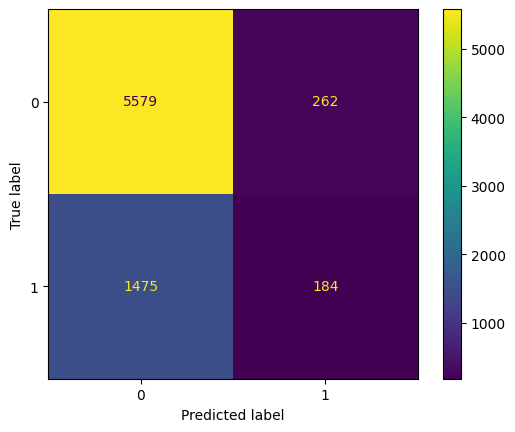

In [22]:
# Predict y and class probabilities on test set
raw_pred = raw_knn.predict(X_test)
raw_pred_proba = raw_knn.predict_proba(X_test)[:,1]

# Print accuracy and auc
print("Raw kNN accuracy:", round(accuracy_score(y_test, raw_pred), 4))
print("Raw kNN auc:", round(roc_auc_score(y_test, raw_pred_proba), 4))

# Display confusion matrix (when using threshold of 0.5 for prediction)
ConfusionMatrixDisplay.from_predictions(y_test, raw_pred)
plt.show()

In [23]:
# Look at what are the closes neighbors for one test instance (in this case the first one)
distances, indices = raw_knn.kneighbors(X_test[:1])

neighbor_table = X_train.iloc[indices[0]].copy()
neighbor_table["default"] = y_train.iloc[indices[0]].values
neighbor_table["distance_to_query"] = distances[0]

print("One example test client:")
display(X_test.iloc[[0]])

print("Nearest neighbors before scaling:")
display(neighbor_table)

One example test client:


,LIMIT_BAL,AGE,PAY_0,BILL_AMT1,BILL_AMT2,BILL_AMT3,PAY_AMT1,PAY_AMT2,PAY_AMT3
16895,50000,45,1,49436,48342,49140,0,2065,1376


Nearest neighbors before scaling:


,LIMIT_BAL,AGE,PAY_0,BILL_AMT1,BILL_AMT2,BILL_AMT3,PAY_AMT1,PAY_AMT2,PAY_AMT3,default,distance_to_query
16845,50000,40,1,49039,47949,49235,0,2058,1400,1,567.215127
13802,50000,46,1,49220,48161,49310,0,2000,1900,1,622.188878
10528,50000,34,1,49378,48052,48573,0,2033,1119,0,690.034057
1583,50000,70,2,49546,48480,48621,0,2200,700,0,881.097043
16541,50000,27,2,49079,47992,48502,0,1842,1770,1,928.591945
11396,50000,32,1,49340,48297,49255,0,3000,1000,0,1019.919605
177,50000,30,1,48860,47801,48363,0,1500,1000,0,1299.619944
25708,50000,45,1,49768,47191,49422,0,3000,1500,0,1550.532167
11452,50000,39,1,50468,48621,49987,0,2600,650,1,1635.118039
21726,50000,22,2,50345,49245,50061,0,1728,1730,1,1652.073243


## Part 2 — Standardize columns and find nearest neighbors

Scaled kNN accuracy: 0.8092
Scaled kNN auc: 0.72


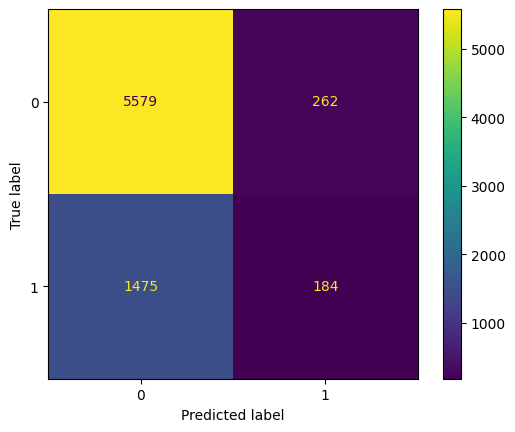

In [24]:
# Defining the object for column standardizing
prep_scaler = Pipeline([
    ("scaler", StandardScaler())
])

# Fit and scale using training data
X_train_scaled = prep_scaler.fit_transform(X_train)
# Also transform test data
X_test_scaled = prep_scaler.transform(X_test)

# Train a regular KNN on scaled X_train
scaled_knn = KNeighborsClassifier(n_neighbors=11)
scaled_knn.fit(X_train_scaled, y_train)

# Make predictions for scaled X_tes
scaled_pred = scaled_knn.predict(X_test_scaled)
scaled_pred_proba = scaled_knn.predict_proba(X_test_scaled)[:,1]

print("Scaled kNN accuracy:", round(accuracy_score(y_test, scaled_pred), 4))
print("Scaled kNN auc:", round(roc_auc_score(y_test, scaled_pred_proba), 4))

ConfusionMatrixDisplay.from_predictions(y_test, raw_pred)
plt.show()

In [25]:
# Find neighbors and scaled distance of the first test row
distances, indices = scaled_knn.kneighbors(X_test_scaled[:1])

# Look at the neighbors in the unscaled X_train
neighbor_table = X_train.iloc[indices[0]].copy()
neighbor_table["default"] = y_train.iloc[indices[0]].values
neighbor_table["distance_to_query"] = distances[0]

print("One example test client:")
display(X_test.iloc[[0]])

print("Nearest neighbors after scaling:")
display(neighbor_table)

One example test client:


,LIMIT_BAL,AGE,PAY_0,BILL_AMT1,BILL_AMT2,BILL_AMT3,PAY_AMT1,PAY_AMT2,PAY_AMT3
16895,50000,45,1,49436,48342,49140,0,2065,1376


Nearest neighbors after scaling:


,LIMIT_BAL,AGE,PAY_0,BILL_AMT1,BILL_AMT2,BILL_AMT3,PAY_AMT1,PAY_AMT2,PAY_AMT3,default,distance_to_query
25708,50000,45,1,49768,47191,49422,0,3000,1500,0,0.049378
13802,50000,46,1,49220,48161,49310,0,2000,1900,1,0.112985
3789,50000,46,1,50471,49399,50556,0,2247,1054,0,0.114568
10979,50000,44,1,49615,48552,50175,0,3056,0,1,0.142791
4145,50000,46,1,43244,42276,45235,0,4000,1600,1,0.196587
12301,50000,45,1,46166,42253,46794,0,5600,0,0,0.215201
14385,50000,43,1,48777,47331,48010,0,2000,1000,0,0.220245
16063,50000,43,1,50738,49236,48608,4,1939,2000,0,0.222013
24677,50000,47,1,50574,48968,50151,0,2463,2300,1,0.226021
15475,50000,46,1,51814,53077,51400,2400,0,0,1,0.236780


## Part 3 - Grid search to find best n_neighbors and compare uniform vs. distance weighted voting

In [26]:
# Defining a pipeline that does both the scaling and KNN classification
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier())
])

# Some parameters of KNeighnorsClassifier you may want to play with
# n_neighbors : Number of neighbors to use by default for kneighbors queries.
# weights : {'uniform', 'distance'}, default='uniform'
#     Weight function used in prediction.
#     'uniform' : All points in each neighborhood are weighted equally.
#     'distance' : Weight points by the inverse of their distance.
# p : float, default=2
#   Power parameter for the Minkowski metric. p = 1 is manhattan_distance (l1), p = 2 is euclidean_distance.
param_grid = {
    "knn__n_neighbors": list(range(5, 100, 5)),
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2]
    }

# Explicit 5-fold CV strategy so we can pass RANDOM_STATE for reproducibility
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Note that we are passing "pipe" which has StandardScaler() inside it
# This is the correct way to do cross-validation so the scaling is done for each fold based on training data of that fold
# This avoids data leakage (e.g if we had first scaled the entire training data set)
grid = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv= cv_strategy,
    scoring="roc_auc", # you can also try "roc_auc", "accuracy"
    n_jobs=-1
)

# This will do the cross validation to find the best parameter
grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV accuracy:", round(grid.best_score_, 4))

Best parameters: {'knn__n_neighbors': 90, 'knn__p': 1, 'knn__weights': 'uniform'}
Best CV accuracy: 0.7602


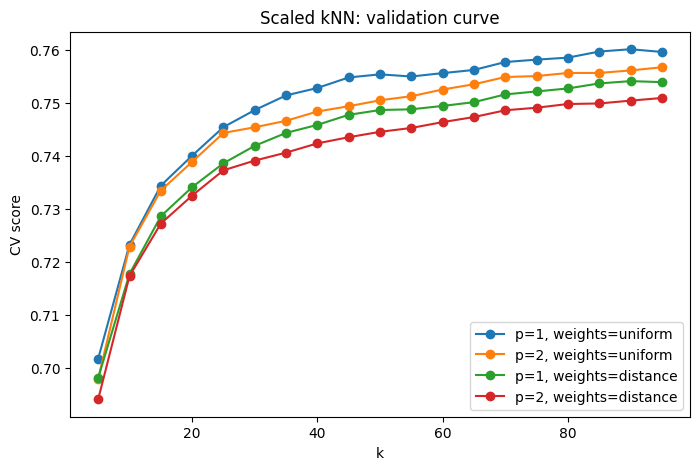

In [27]:
# Visualization only -- cv score vs k for the four combinations of
# (weights = uniform, weights = distance) vs (p=1, p=2)
results = pd.DataFrame(grid.cv_results_)

plt.figure(figsize=(8, 5))
for weights in ["uniform", "distance"]:
  for p in [1, 2]:
    sub = results[(results["param_knn__weights"] == weights) & (results['param_knn__p'] == p)]
    plt.plot(
        sub["param_knn__n_neighbors"].astype(int),
        sub["mean_test_score"],
        marker="o",
        label = f"p={p}, weights={weights}"
    )

plt.xlabel("k")
plt.ylabel("CV score")
plt.title("Scaled kNN: validation curve")
plt.legend()
plt.show()

In [28]:
# GridSearchCV.best_estimator_ gives the estimator that was chosen by the search
#  i.e. the parameters that gave the highest score on the left out data
#  are used to refit an estimator on the whole dataset
best_knn = grid.best_estimator_
scaled_pred = best_knn.predict(X_test)
scaled_pred_proba = best_knn.predict_proba(X_test)[:,1]

print("Unscaled test accuracy:", round(accuracy_score(y_test, raw_pred), 4))
print("Unscaled test roc:", round(roc_auc_score(y_test, raw_pred_proba), 4))
print("Scaled/tuned test accuracy:", round(accuracy_score(y_test, scaled_pred), 4))
print("Scaled/tuned test roc:", round(roc_auc_score(y_test, scaled_pred_proba), 4))

# ConfusionMatrixDisplay.from_predictions(y_test, scaled_pred)
# plt.show()

Unscaled test accuracy: 0.7684
Unscaled test roc: 0.6379
Scaled/tuned test accuracy: 0.814
Scaled/tuned test roc: 0.7559


## Exercise
Try logistic regression, decision trees, and ensemble methods on this dataset, and compare and contrast how they perform